In [1]:
from qiskit.circuit import QuantumCircuit, QuantumRegister, AncillaRegister
from qiskit.circuit.library import StatePreparation, DiagonalGate
from qiskit.quantum_info import Statevector, Operator
# from qiskit_algorithms import PhaseEstimation


import matplotlib.pyplot as plt
import numpy as np

# Quantum Amplitude Amplification and Quantum Mean Estimation

Tom Alberts

*July 10, 2026*

## Summary

This notebook implements, tests, and applies algorithms for *non-boolean* [Quantum Amplitude Amplification](https://en.wikipedia.org/wiki/Amplitude_amplification) and [Quantum Mean Estimation](https://quantumopsschool.com/blog/quantum-mean-estimation/). Here the term *non-boolean* refers to the type of oracle available to the algorithm. In the more typical boolean case, one is provided with a (classical) function $f : \{ 0, 1 \}^n \to \{ 0, 1 \}$ and an associated *phase oracle* that acts on basis states via
$$
U_f \ket{x} = (-1)^{f(x)} \ket{x}.
$$
In the non-boolean case the setup is generalized to having a phase function $\varphi : \{ 0, 1 \}^n \to \mathbb{R}$ as a replacement for $f$, and an associated oracle that acts on basis states via
$$
U_{\varphi} \ket{x} = e^{i \varphi(x)} \ket{x}.
$$
Note that the boolean case is a special choice of the non-boolean one via the choice $\varphi_f(x) = \pi f(x)$.

In boolean quantum amplitude estimation, the goal is to use $U_f$ to find states $x$ satisfying $f(x) = 1$. In non-boolean quantum amplitude estimation this is generalized to finding states $x$ where $\cos \varphi(x)$ is small (close to $-1$).  

The algorithms presented here are based on the paper <a href="#shyamsundar2021">*Non-Boolean Quantum Amplitude Amplification and Quantum Mean Estimation* by Shyamsundar</a>.  

## Non-Boolean Quantum Amplitude Amplification

### Algorithm

The underlying algorithm is a relatively simple generalization of the idea underlying Grover's algorithm. One extra ancilla qubit is introduced, and the reflection and oracle operators are adjusted slightly to account for this ancilla.

More specifically, given $\varphi : \{ 0, 1 \}^n \to \mathbb{R}$, the oracle operator $U_{\varphi}$ is expanded to the operator $\operatorname{U}_{\varphi}$ given by
$$
\operatorname{U}_{\varphi} = \ket{0} \bra{0} \otimes U_{\varphi} + \ket{1} \bra{1} \otimes U_{\varphi}^{\dagger}.
$$
Since $U_{\varphi}^{\dagger} \ket{x} = e^{- i \varphi(x)} \ket{x}$ on basis states, the expanded oracle operator shifts the phase of $\ket{0, x}$ by $\varphi(x)$ and the phase of $\ket{1, x}$ by $-\varphi(x)$.


Let $\psi_0$ be an initial state for the second register. It will act as the initial state whose amplitudes are sought to be amplified. Often the initial state is taken to be $\psi_0 = H^{\otimes n} \ket{0^n}$. With $\psi_0$ chosen, define
$$
\operatorname{S}_{\psi_0} = 2 \ket{+, \psi_0} \bra{+, \psi_0} - I
$$


<div class="alert alert-block alert-warning">
<b>Algorithm</b>: Define the operator $Q_{iter}$ by
$$
Q_{\text{iter}} = \operatorname{S}_{\psi_0} \operatorname{U}_{\varphi} [X \otimes I]
$$
where $X$ is the <emph>not</emph> operator on the ancilla state. Fix an integer $K \geq 1$. Then compute
$$
Q_{\text{iter}}^K \ket{\mathbf{\Psi_0}}
$$
and measure the output of the ancilla state in the $0/1$ basis.
</div>

The purpose of measuring the ancilla state is to ensure that it is unentangled with the remaining register. The statement is that with high probability, the distribution on basis states induced by $Q_{\text{iter}}^K \ket{\mathbf{\Psi_0}}$ will be highly concentrated on states where $\cos \varphi(x)$ is close to $-1$.

#### Probability distribution on basis states after $K$ iterations

Shyamsundar's paper gives an explicit formula for the probability distribution on basis states $\{ 0, 1 \}^n$ induced by the non-boolean quantum amplitude amplification algorithm. Let $p_K : \{ 0, 1 \}^n \to [0,1]$ be the probability distribution on $\{ 0, 1 \}^n$ induced by $Q_{\text{iter}}^K \ket{\mathbf{\Psi_0}}$. Then $p_0(x) = \braket{x | \psi_0}^2$ and
$$
p_K(x) = p_0(x) \left \{ 1 - \lambda_K \left[ \cos \varphi(x) - \cos \theta \right] \right \},
$$
where $\lambda_K$ is the real number given by
$$
\lambda_K = \frac{\cos \theta - \cos ((2K+1) \theta)}{\sin^2 \theta}.
$$
The quantity $\theta$ is defined by the requirement that $\theta \in [0, \pi]$ and the formula 
$$
\cos \theta = \sum_{x \in \{0, 1\}^n} \braket{x | \psi_0}^2 \cos \varphi(x).
$$
Note that $\cos \theta$ is implicitly defined by the choice of $\psi_0$ and $\varphi$, but the dependence on that choice is suppressed in the notation.

Estimating $\theta$ is the focus of the section on quantum mean estimation, so more details can be found there. 



In [2]:
def lambdaK(K, theta):
    return (np.cos(theta) - np.cos((2*K+1)*theta))/(np.sin(theta)**2)

# return [1 - lambda_K * (cos phi(x) - cos theta)]
def unscaled_pK(phix, K, theta):
    lk = lambdaK(K, theta)
    return (1 - lk*(np.cos(phix) - np.cos(theta)))

#### Comparison with the Boolean Amplitude Amplification Algorithm

The major difference with the boolean amplitude amplification algorithm is that both $U_{\varphi}$ and $U_{\varphi}^{\dagger}$ are used in the non-boolean case. In the boolean case $U_{f}^{\dagger} = U_f$, so the difference is not noticed.

### Implementation

This section implements Shyamsundar's method for non-boolean amplitude amplification. The relevant method are:

- **NonBooleanAmplifier**: The main method. Call this to carry out amplitude amplification.
- **QIter**: A helper method. The iterator used by the amplitude amplification algorithm.

In [3]:
# diagonal operator, where the sign of the phase depends on the ancilla value


# Input: phi a real-valued vector of length 2^d for some integer d
# Output: a diagonal operator, of size 2^(d+1) to account for the ancilla
def U(d, phi):
    # create an ancilla register and a qubit register and join them together into a circuit
    ancilla_register = AncillaRegister(1, name="ancilla")
    oracle_register = QuantumRegister(d, name="working")
    qc = QuantumCircuit(ancilla_register, oracle_register, name="conditional oracle")

    diagonal_part = []

    # loop through the ancilla values
    for a in [0,1]:
        for x in range(2**d):
            if a == 0:
                phase = np.exp(1j * phi[x])
            else:
                phase = np.exp(-1j * phi[x])
            
            diagonal_part.append(phase)

    # create the diagonal gate with the Qiskit Diagonal method
    diagonal_gate = DiagonalGate(diagonal_part)
    qc.append(diagonal_gate, qc.qubits)
    
    return qc

# implements the reflector 2 |0><0| - I
def zero_reflector(d):
    qc = QuantumCircuit(d, name = "R_0")

    # first produce I - 2|0><0|
    # negate all gates
    qc.x(range(d))

    # apply Hadarmard + not + Hadamard on 1st bit
    qc.h(0)
    qc.mcx(list(range(1,d)), 0)
    qc.h(0)

    # negate all gates again
    qc.x(range(d))

    # negate the operator to get 2|0><0| - I
    qc.global_phase += np.pi

    return qc

# reflection operator across the state |+, psi>, for psi fixed
# assumes there is a preparation operator that sends |0^d> to |psi>
def reflection_from_preparation(d, prep):
    # create an ancilla register and a qubit register and join them together into a circuit
    ancilla_register = AncillaRegister(1, name="ancilla")
    oracle_register = QuantumRegister(d, name="reflector")
    qc = QuantumCircuit(ancilla_register, oracle_register, name="searcher")

    # apply Hadarmard to ancilla
    qc.h(ancilla_register[:])

    # apply inverse of prep to reflector bits
    prep_inverse = prep.inverse()
    qc.append(prep_inverse.to_gate(), oracle_register[:])

    # apply the zero reflector on all d+1 bits
    ZR = zero_reflector(d+1)
    qc.append(ZR.to_gate(), [*ancilla_register, *oracle_register])

    # apply prep to the reflector bits
    qc.append(prep.to_gate(), oracle_register[:])

    # apply Hadamard to ancilla
    qc.h(ancilla_register[:])

    return qc

# reflection operator across a fixed state psi, tensored with the |+> state
def reflection_from_statevector(d, psi):
    oracle_register = QuantumRegister(d, name="working")
    qc = QuantumCircuit(oracle_register, name="prep")

    qc.prepare_state(psi, oracle_register[:])
    
    return reflection_from_preparation(d, qc)

# reflection operator across a fixed state psi, tensored with the |+> state
# shorthand version of the reflection_from_statevector method
def S(d, psi):
    return reflection_from_statevector(d, psi)

# amplifier used by Shyamsundar paper
def QIter(d, psi, phi):

    # create an ancilla register and a qubit register and join them together into a circuit
    ancilla_register = AncillaRegister(1, name="ancilla")
    oracle_register = QuantumRegister(d, name="oracle")
    qc = QuantumCircuit(ancilla_register, oracle_register, name="QIter")

    # negate the ancilla register
    qc.x(ancilla_register[0])

    # add the oracle operator
    sub_oracle_circ = U(d, phi)
    sub_oracle_gate = sub_oracle_circ.to_gate()
    qc.append(sub_oracle_gate, qc.qubits)

    # add the reflection operator
    sub_reflector_circ = S(d, psi)
    sub_reflector_gate = sub_reflector_circ.to_gate()
    qc.append(sub_reflector_gate, qc.qubits)

    return qc


# circuit for non-boolean amplification with k amplification steps
# strings together k iterations of the Qiter circuit
def NonBooleanAmplifier(k, d, psi, phi):

    # create an ancilla register and a qubit register and join them together into a circuit
    ancilla_register = AncillaRegister(1, name="ancilla")
    oracle_register = QuantumRegister(d, name="oracle")
    qc = QuantumCircuit(ancilla_register, oracle_register, name="amplifier")
    

    # create a QIter gate and append it together k times
    Qiter = QIter(d, psi, phi)
    Qiter_gate = Qiter.to_gate()
    for i in range(k):
        qc.append(Qiter_gate, qc.qubits)

    return qc


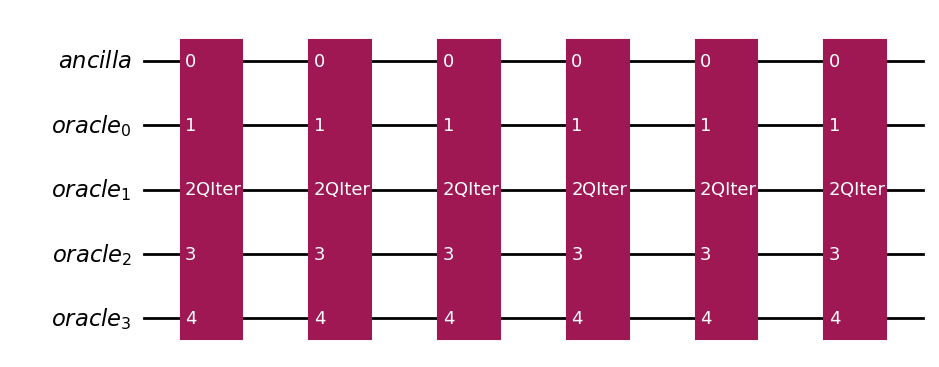

In [4]:
testphi = [(x/15)*(np.pi/4) for x in range(16)]
testpsi = Statevector.from_label('1011')
testQiter = QIter(4, testpsi, testphi)

mycirc = NonBooleanAmplifier(6, 4, testpsi, testphi)

mycirc.draw(output="mpl")

### Testing

In this section we test Shyamsundar's non-boolean amplitude amplification algorithm. This requires a choice of $d$ and the phase function $\varphi(x)$. We use the test suggested in Shyamsundar's paper: $d = 8$ with $\varphi(x)$ given by
$$
\varphi(x) = \frac{x}{255} \frac{\pi}{4}
$$
Here $\varphi : \{ 0, 1 \}^8 \to \mathbb{R}$, but in the above the input is represented with its integer value of the binary string $x$:




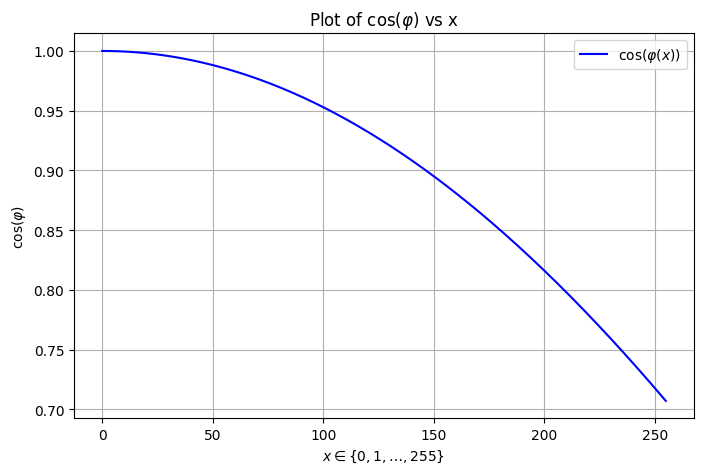

In [5]:
testx = [(x * np.pi)/(255 * 4) for x in range(256)]
testphi = [np.cos(t) for t in testx]

# Plot the data
plt.figure(figsize=(8, 5))  # Sets the window size
plt.plot(range(256), testphi, label=r'$\cos(\varphi(x))$', color='blue')

# Add labels, title, and styling
plt.xlabel(r'$x \in \{0, 1, \ldots, 255 \}$')
plt.ylabel(r'$\cos(\varphi)$')
plt.title(r'Plot of $\cos(\varphi)$ vs x')
plt.grid(True)  # Adds a helpful grid
plt.legend()

plt.show()

Recall that the algorithm favors values of $x$ where $\cos(\varphi(x))$ is small, i.e. close to $-1$. From the graph we see that the algorithm should return values of $x$ close to $255$ then.

For testing purposes let's assume that we make the choice $\ket{\psi_0} = \ket{+^d}$. Under this assumption we are effectively making the choice that $p_0(x) = 2^{-8}$ for all strings $x$. That is, all strings are equally likely. For this choice of $\varphi(x)$, $\psi_0$, and $d = 8$, the definition of $\cos \theta$ gives
$$ 
\cos \theta = \sum_{x \in \{ 0, 1 \}^8} \braket{x | \psi_0}^{2} \cos \varphi(x) = 2^{-8} \sum_{x \in \{ 0, 1 \}^8} \cos \varphi(x) = 2^{-8} \sum_{x \in \{ 0, 1 \}^8 } \cos \left( \frac{x}{255} \frac{\pi}{4} \right) \approx \int_0^{1} \cos( \pi t / 4 ) \, dt = \frac{4}{\pi} \, \sin(\pi/4) = \frac{2 \sqrt{2}}{\pi}
$$
From this we infer that $\theta = \arccos(2 \sqrt{2}/\pi) \approx .450301$

In [6]:
test_theta = np.arccos(2 * np.sqrt(2)/ np.pi)

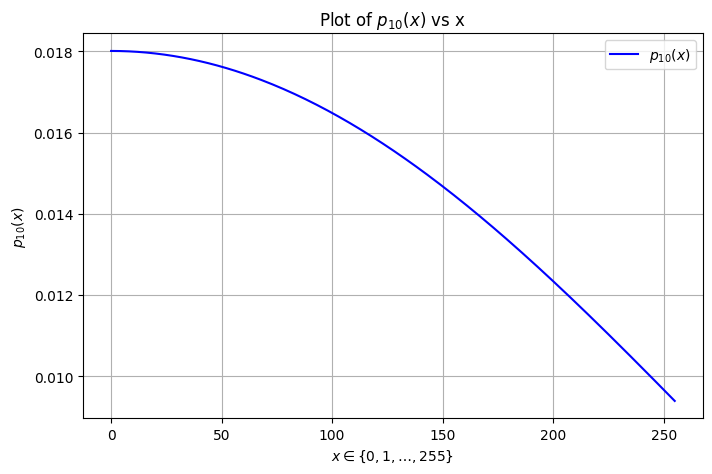

In [7]:
# generate a plot of p_K(x) as a function of x
pkx = [unscaled_pK(t, 10, test_theta)/256 for t in testphi]


# Plot the data
plt.figure(figsize=(8, 5))  # Sets the window size
plt.plot(range(256), pkx, label=r'$p_{10}(x)$', color='blue')

# Add labels, title, and styling
plt.xlabel(r'$x \in \{0, 1, \ldots, 255 \}$')
plt.ylabel(r'$p_{10}(x)$')
plt.title(r'Plot of $p_{10}(x)$ vs x')
plt.grid(True)  # Adds a helpful grid
plt.legend()

plt.show()

### Application

Non-boolean quantum amplitude estimation can be useful for constructing a sampler for a given probability distribution. It is particularly well suited for probability distributions on space $\{ 0, 1 \}^E$, where $E$ is some index set. 

In this section we give two examples of these samplers: for the **Ising model on the hypercube** and **perfect matchings of a graph**.

#### Ising Model on the Hypercube

In the hypercube setting the Ising model can be viewed as a particular probability distribution on $\{ 0, 1 \}^d$, for a given positive integer $d$. It is often called a hypercube because a binary string $x_1 \ldots x_d$ is often viewed as a point $(x_1, \ldots, x_d) \in \mathbb{R}^d$, and then the collection of all binary strings is in bijection with the vertices of the cube $[0, 1]^d$. The neighbor relation between vertices is inherited from the hypercube, which leads to the following definition.

<div class="alert alert-block alert-info">
<b>Definition:</b> Two strings $x, y \in \{ 0, 1 \}^n$ are neighbors iff the two strings differ at exactly one bit. We denote this by $x \sim y$. 
</div>

The Ising model is a probability measure on the set of spin assignments to vertices:
$$
\Omega_n := \left \{ \sigma : \{ 0 , 1 \}^n \to \{+1, -1 \} \right \}.
$$
Note that because $|\{ 0, 1 \}^n| = 2^n$ it follows that $|\Omega_n| = 2^{2^n}$. A general probability measure on $\Omega_n$ can quickly become complicated, and sampling from it can be time consuming. The Ising model has some extra structure which makes the probability distribution somewhat tractable. The distribution is defined through a [Gibbs measure](https://en.wikipedia.org/wiki/Gibbs_measure) with a specific Hamiltonian (energy function).

<div class="alert alert-block alert-info">
<b>Definition:</b> Fix parameters $J > 0$ and $h \in \mathbb{R}$, and then define the <b>Hamiltonian</b> $H : \Omega_n \to \R$ by
    \[
H(\sigma) = -J \sum_{x \sim y} \sigma_x \sigma_y - h \sum_x \sigma_x.
    \]
Then, for a fixed inverse temperature parameter $\beta$, the <b>Ising probability distribution</b> on $\Omega_n$ is
    \[
\mathbb{P}_n(\sigma) := \frac{e^{- \beta H(\sigma)}}{Z_{\beta, n}},
    \]
where $Z_{\beta, n}$ is the partition function (normalization constant) given by
    \[
Z_{\beta, n} = \sum_{\sigma \in \Omega_n} e^{- \beta H(\sigma)}.
    \]
</div>


## Non-Boolean Quantum Mean Estimation

Recall the unitary operator $U_{\varphi}$ introduced above. The non-boolean quantum mean estimator is an efficient way of computing the quadratic form
$$
\bra{\psi_0} U_{\varphi} \ket{\psi_0}
$$
for a given vector $\psi_0$. This quadratic form can be nicely re-expressed in terms of a probabilistic expected value. To see it, let $\psi_0$ have the expansion into standard basis states given by
$$
\psi_0 = \sum_{x \in \{0, 1 \}^n} a_0(x) \ket{x}.
$$
Then by the defining formula for $U_{\varphi}$ and straightforward computation we have
$$
\bra{\psi_0} U_{\varphi} \ket{\psi_0} = \sum_{x \in \{0,1\}^n} |a_0(x)|^2 e^{i \varphi(x)} = \mathbb{E}_{\psi_0}[\cos \varphi(x)] + i \mathbb{E}_{\psi_0}[\sin \varphi(x)].
$$
Here $\mathbb{E}_{\psi_0}$ refers to the probability measure on $x \in \{0, 1\}^n$ given by $\mathbb{P}_{\psi_0}(x) = \braket{x | \psi_0}^2 = |a_0(x)|^2$. Since $-1 \leq \mathbb{E}_{\psi_0}[\cos \varphi(x)] \leq 1$, it is possible to make the following definition.

<div class="alert alert-block alert-info">
<b>Definition</b>: For $\psi_0 \in (\mathbb{C}^2)^n$ fixed with $||\psi_0||^2 = 1$ and $\varphi : \{0, 1\}^n \to \mathbb{R}$ given, define an angle $\theta \in [0, \pi)$ by
$$
\cos \theta = \mathbb{E}_{\psi_0}[\cos \varphi(x)] = \sum_{x \in \{0, 1\}^n} |a_0(x)|^2 \cos \varphi(x) = \sum_{x \in \{0, 1\}^n} \braket{x | \psi_0}^2 \cos \varphi(x).
$$
Although $\theta$ depends on the choice of $\psi_0$ and $\varphi$, the dependence on them is suppressed in the notation.    
</div>

Chapter 4 of Shyamsundar's paper points out a method for estimating $\cos \theta$, which is the real part of $\bra{\psi_0} U_{\varphi} \ket{\psi_0}$. Then the imaginary part can be computed from the estimate of $\cos \theta$ (up to sign), or the algorithm can be adapted to compute $\sin \theta$ directly.

### Algorithm

There is no separate algorithm introduced by Shyamsundar's paper. The computation of the mean is instead reduced to the [quantum phase estimation](https://en.wikipedia.org/wiki/Quantum_phase_estimation_algorithm) (QPE) algorithm. 

<div class="alert alert-block alert-warning">
<b>Algorithm</b>: Apply the quantum phase estimation algorithm with $Q_{\text{iter}}$ as the unitary operator and $\ket{\mathbf{\Psi_0}}$ acting as the eigenstate required by the QPE algorithm. Let $\hat{\omega} \in [0, 2 \pi)$ be the estimate of the phase angle. Then return $\cos \hat{\omega}$ as an estimate for $\cos \theta$.
</div>

Note that $\ket{\mathbf{\Psi_0}}$ is *not* an eigenvector of $Q_{\text{iter}}$. In fact, one can show that
$$
Q_{\text{iter}} \ket{\mathbf{\Psi_0}} = \left( 2 \cos \theta \cdot I - \operatorname{U}_{\varphi} \right) \ket{\mathbf{\Psi_0}}.
$$
However, the algorithm still works because of the following property: that there are normalized eigenvectors $\ket{\mathbf{\eta_{\pm}}}$ of $Q_{\text{iter}}$ that satisfy
$$
Q_{\text{iter}} \ket{\mathbf{\eta_{\pm}}} = e^{\pm i \theta} \ket{\mathbf{\eta_{\pm}}}, \quad \ket{\mathbf{\Psi_0}} = \frac{\ket{\mathbf{\eta_+}} - \ket{\mathbf{\eta_-}}}{\sqrt{2}}.
$$
By the latter two properties, Shyamsundar's application of the phase estimation algorithm will return an estimate of $\theta$ with probability $1/2$ or an estimate of $-\theta$ with probability $1/2$. Since $\cos \theta = \cos (-\theta)$, the algorithm always returns an estimate of $\cos \theta$.

### Implementation

### Testing

## References

<a id="shyamsundar2021"></a>
* **Shyamsundar, P. (2021).** *Non-Boolean Quantum Amplitude Amplification and Quantum Mean Estimation.* Quantum Inf Process **22**, 423 (2023). doi: [10.1007/s11128-023-04146-3](https://doi.org/10.1007/s11128-023-04146-3)